# Quick Exploratory Data Analysis:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import geopandas as gpd

In [2]:
df = pd.read_excel('L005169-082426.xlsx')
df.head()

,Agency,ID_Incident,StartDate,Contained,Controlled,County,FireName,Lat,Long,acres,CauseGeneral,CauseSpecific,CauseSpecificDetail,Department,BadLocation,IrwinID,Shape
0,FD,AEA0A967-E4C9-45C3-BD5F-0000D3C0A9DD,2011-07-17 00:00:00,NaT,NaT,Wichita,Rekindle Krohn Rd,34.091480,-98.898642,0.0,Other causes,Other (remarks required),Unknown (remarks required),Electra VFD,0,NaN,0xE6100000010CF833BC5983B958C0CD1C37A1B50B4140
1,FD,5E7D8AA7-872F-4C28-849C-0001031ACCD5,2020-04-08 12:59:00,2020-04-08 13:16:00,2020-04-08 13:52:00,Aransas,190,28.057600,-97.104200,0.1,Debris and open burning,Hand pile/slash,Unknown (remarks required),Rockport VFD,0,NaN,0xE6100000010C910F7A36AB4658C0E63FA4DFBE0E3C40
2,FD,A9DBA206-FB1E-4061-9500-0001FC0A547D,2009-04-25 00:00:00,NaT,NaT,Bee,Grass Fire,28.413202,-97.723735,0.5,Smoking,Cigar/cigarette/pipe,Unknown (remarks required),Beeville Vol. Fire Dept.,0,NaN,0xE6100000010C000B70AC516E58C07CD43EA1C7693C40
3,FD,E47D6494-9964-4F0A-B4F8-0002615830C7,2008-01-29 00:00:00,NaT,NaT,Bell,7000 Stillman Valley,30.934168,-97.716991,20.0,Debris and open burning,Hand pile/slash,Unknown (remarks required),Florence VFD,0,NaN,0xE6100000010C5002F62CE36D58C0344205A825EF3E40
4,FD,7CD8FF55-5E90-450B-8687-0002A206891B,2008-06-17 00:00:00,NaT,NaT,Mills,Stone Creek #3,31.557167,-98.665667,1.0,Other causes,Other (remarks required),Unknown (remarks required),Mullin Volunteer Fire Department,0,NaN,0xE6100000010C874215489AAA58C01E1F6779A28E3F40


In [3]:
df.shape

(285858, 17)

In [4]:
print("Amount of Duplicates:",df.duplicated().sum())

Amount of Duplicates: 0


In [5]:
df.info(verbose=True,show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285858 entries, 0 to 285857
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Agency               285858 non-null  object        
 1   ID_Incident          285858 non-null  object        
 2   StartDate            285858 non-null  datetime64[ns]
 3   Contained            97945 non-null   datetime64[ns]
 4   Controlled           101968 non-null  datetime64[ns]
 5   County               285858 non-null  object        
 6   FireName             285361 non-null  object        
 7   Lat                  285613 non-null  float64       
 8   Long                 285613 non-null  float64       
 9   acres                285858 non-null  float64       
 10  CauseGeneral         285808 non-null  object        
 11  CauseSpecific        285751 non-null  object        
 12  CauseSpecificDetail  228386 non-null  object        
 13  Department    

In [6]:
(df.isnull().sum()/len(df))*100

Agency                  0.000000
ID_Incident             0.000000
StartDate               0.000000
Contained              65.736485
Controlled             64.329142
County                  0.000000
FireName                0.173863
Lat                     0.085707
Long                    0.085707
acres                   0.000000
CauseGeneral            0.017491
CauseSpecific           0.037431
CauseSpecificDetail    20.105087
Department              0.000000
BadLocation             0.000000
IrwinID                96.132345
Shape                   0.000000
dtype: float64

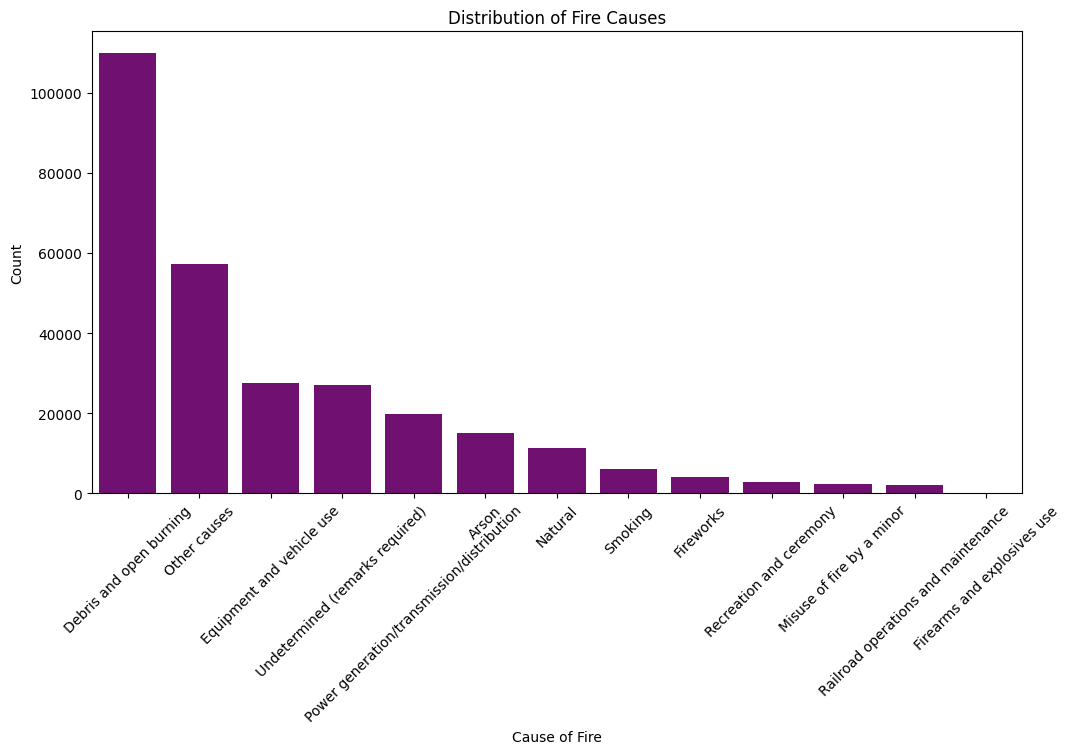

In [7]:
plt.figure(figsize=(12,6))
sns.countplot(x='CauseGeneral', data=df, color='purple', order=df['CauseGeneral'].value_counts().index)
plt.title('Distribution of Fire Causes')
plt.xlabel('Cause of Fire')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [8]:
df["CauseGeneral"].nunique()

13

In [9]:
df["CauseGeneral"].value_counts()

CauseGeneral
Debris and open burning                       109837
Other causes                                   57328
Equipment and vehicle use                      27647
Undetermined (remarks required)                27020
Power generation/transmission/distribution     19851
Arson                                          15027
Natural                                        11333
Smoking                                         6150
Fireworks                                       4153
Recreation and ceremony                         2933
Misuse of fire by a minor                       2404
Railroad operations and maintenance             2044
Firearms and explosives use                       81
Name: count, dtype: int64

In [10]:
df["CauseSpecific"].nunique()

68

In [11]:
df["CauseSpecific"].value_counts()

CauseSpecific
Other (remarks required)               79041
Hand pile/slash                        41297
Open trash burning                     28596
Origin and/or cause not identified     20123
Unknown (remarks required)             18375
                                       ...  
Right-of-way vegetation maintenance        1
Ceremonial fire                            1
Black powder/muzzle loading                1
Blasting                                   1
Glass refraction/magnifying glass          1
Name: count, Length: 68, dtype: int64

In [12]:
df["CauseSpecificDetail"].nunique()

54

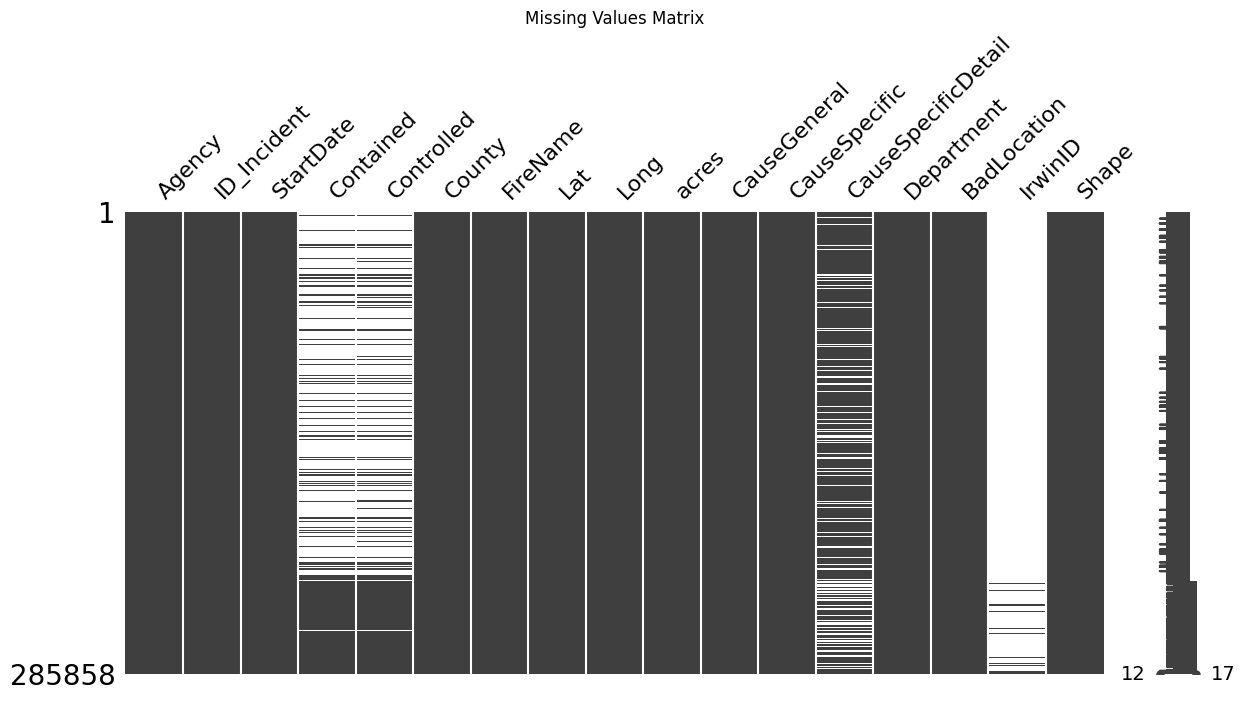

In [13]:
msno.matrix(df, figsize=(14, 6))
plt.title("Missing Values Matrix")
plt.show()

In [14]:
df["Has_detail"] = df["CauseSpecificDetail"].notna()

In [15]:
cause_gen_comp = pd.crosstab(
    df["CauseGeneral"], df["Has_detail"], margins=True, normalize="index"
)
print(cause_gen_comp)

Has_detail                                     False      True
CauseGeneral                                                  
Arson                                       0.927464  0.072536
Debris and open burning                     0.002750  0.997250
Equipment and vehicle use                   0.005389  0.994611
Firearms and explosives use                 0.074074  0.925926
Fireworks                                   0.000722  0.999278
Misuse of fire by a minor                   1.000000  0.000000
Natural                                     1.000000  0.000000
Other causes                                0.000942  0.999058
Power generation/transmission/distribution  0.007657  0.992343
Railroad operations and maintenance         1.000000  0.000000
Recreation and ceremony                     0.003750  0.996250
Smoking                                     0.001138  0.998862
Undetermined (remarks required)             1.000000  0.000000
All                                         0.200911  0

In [16]:
# Group by both general and specific cause to see missing detail rates
detail_coverage = (
    df.groupby(["CauseGeneral", "CauseSpecific"])["Has_detail"]
    .agg(total_count="count", detail_count="sum", proportion_present="mean")
    .reset_index()
)

# Sort to find categories with lowest detail coverage
# print(
#     detail_coverage.sort_values(by="proportion_present", ascending=True).head(
#         10
#     )
# )
detail_coverage

,CauseGeneral,CauseSpecific,total_count,detail_count,proportion_present
0,Arson,Device,4,0,0.000000
1,Arson,Hot set,35,0,0.000000
2,Arson,Other (remarks required),13582,919,0.067663
3,Arson,Unknown (remarks required),1404,171,0.121795
4,Debris and open burning,Branding,6,4,0.666667
...,...,...,...,...,...
86,Smoking,Unknown (remarks required),149,149,1.000000
87,Undetermined (remarks required),Not investigated,6781,0,0.000000
88,Undetermined (remarks required),Origin and/or cause not identified,20123,0,0.000000
89,Undetermined (remarks required),Origin destroyed,42,0,0.000000


In [17]:
detail_coverage[detail_coverage["detail_count"] > 0]

,CauseGeneral,CauseSpecific,total_count,detail_count,proportion_present
2,Arson,Other (remarks required),13582,919,0.067663
3,Arson,Unknown (remarks required),1404,171,0.121795
4,Debris and open burning,Branding,6,4,0.666667
5,Debris and open burning,Burn Barrel,75,47,0.626667
6,Debris and open burning,Burning personal items,50,34,0.680000
...,...,...,...,...,...
82,Recreation and ceremony,Outdoor oven/fireplace/metal fire ring,6,6,1.000000
83,Recreation and ceremony,Unknown (remarks required),3,3,1.000000
84,Smoking,Cigar/cigarette/pipe,6000,5993,0.998833
85,Smoking,Other (remarks required),1,1,1.000000


In [18]:
# 1. Fast, explicit datetime conversion using your exact format
date_fmt = "%Y-%m-%d %H:%M:%S"

df["StartDate"] = pd.to_datetime(df["StartDate"], format=date_fmt, errors="coerce")
df["Contained"] = pd.to_datetime(df["Contained"], format=date_fmt, errors="coerce")
df["Controlled"] = pd.to_datetime(df["Controlled"], format=date_fmt, errors="coerce")

# 2. Vectorized EndDate selection
end_date = df["Controlled"].fillna(df["Contained"])

# 3. Mask valid rows and create clean working DataFrame
valid_mask = df["StartDate"].notna() & end_date.notna()
df_valid = df[valid_mask].copy()

# 4. Vectorized duration calculation in HOURS using numpy timedelta
df_valid["FireDurationHours"] = (
    end_date[valid_mask] - df_valid["StartDate"]
) / np.timedelta64(1, "h")

# 5. Filter out negative duration anomalies
df_valid = df_valid[df_valid["FireDurationHours"] >= 0]

print(f"Successfully processed {len(df_valid):,} records.")
print(df_valid["FireDurationHours"].describe())

Successfully processed 101,807 records.
count    101807.000000
mean         23.917059
std         433.553559
min           0.000000
25%           0.764167
50%           3.183333
75%          17.816667
max       87691.450000
Name: FireDurationHours, dtype: float64


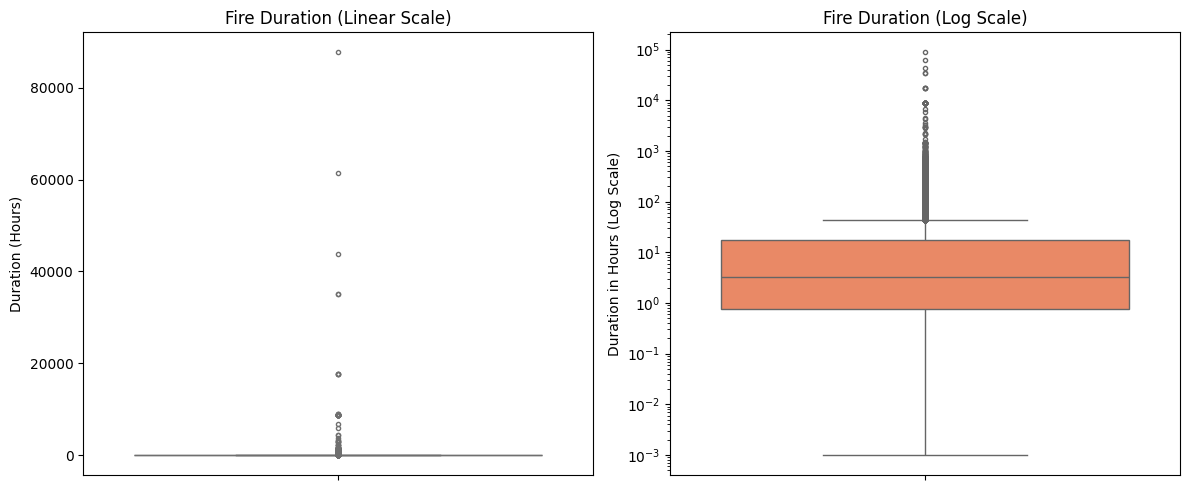

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Standard Linear Scale Boxplot
sns.boxplot(
    y=df_valid["FireDurationHours"],
    ax=axes[0],
    color="skyblue",
    fliersize=3,
)
axes[0].set_title("Fire Duration (Linear Scale)")
axes[0].set_ylabel("Duration (Hours)")

# 2. Log Scale Boxplot (adding +0.001 offset to handle 0-day durations safely)
sns.boxplot(
    y=df_valid["FireDurationHours"] + 0.001,
    ax=axes[1],
    color="coral",
    fliersize=3,
)
axes[1].set_yscale("log")
axes[1].set_title("Fire Duration (Log Scale)")
axes[1].set_ylabel("Duration in Hours (Log Scale)")

plt.tight_layout()
plt.show()

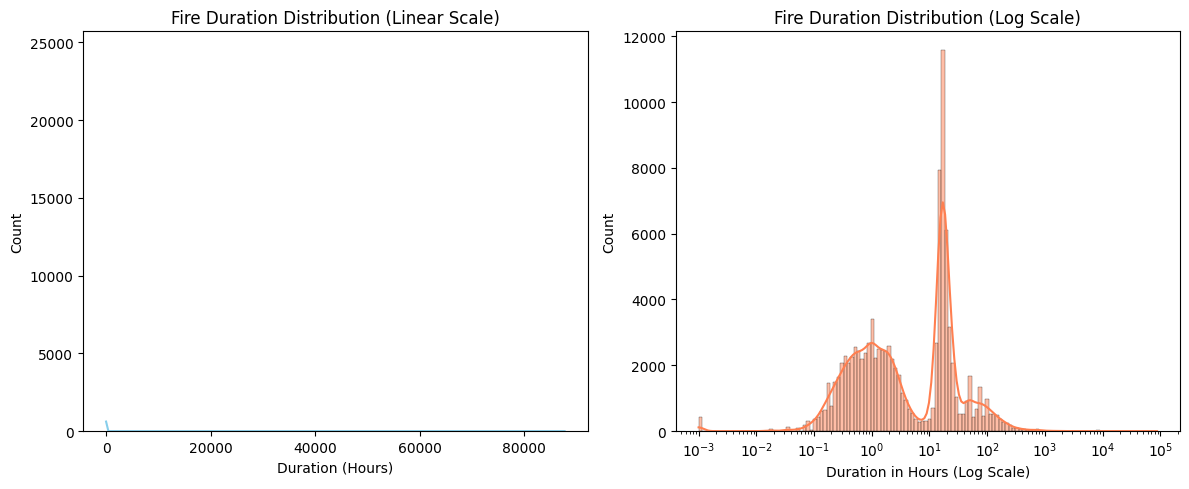

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Standard Linear Scale Histogram
sns.histplot(
    data=df_valid,
    x="FireDurationHours",
    ax=axes[0],
    color="skyblue",
    kde=True,  # Optional: set to False if you don't want the density curve
)
axes[0].set_title("Fire Duration Distribution (Linear Scale)")
axes[0].set_xlabel("Duration (Hours)")
axes[0].set_ylabel("Count")

# 2. Log Scale Histogram
# Adding offset +0.001 to handle 0-hour values safely before taking log
sns.histplot(
    x=df_valid["FireDurationHours"] + 0.001,
    ax=axes[1],
    color="coral",
    log_scale=True,  # Automatically calculates log-spaced bin widths
    kde=True,
)
axes[1].set_title("Fire Duration Distribution (Log Scale)")
axes[1].set_xlabel("Duration in Hours (Log Scale)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()